In [20]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('diabetes2.csv')

In [3]:
data.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Report
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1


In [4]:
X=data.drop(columns='Report',axis=1)
Y=data['Report']

In [5]:
scaler=StandardScaler()
scaler.fit(X)
StandardScaler(copy=True,with_mean=True,with_std=True)
standardized_data=scaler.transform(X)
print(standardized_data)

[[ 0.84832379  0.14964075  0.90726993 ...  0.20401277  0.46849198
   1.4259954 ]
 [-1.12339636 -0.16054575  0.53090156 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.94372388 -0.26394125 -1.28821221 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.00330087  0.14964075  0.15453319 ... -0.73518964 -0.68519336
  -0.27575966]
 [ 0.1597866  -0.47073225 -1.28821221 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.8730192   0.04624525  0.65635768 ... -0.20212881 -0.47378505
  -0.87137393]]


In [6]:
X=standardized_data
Y=data['Report']

In [7]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2
,stratify=Y,random_state=2)

In [8]:
print(X.shape,X_train.shape,X_test.shape)
classifier=svm.SVC(kernel='linear')
classifier.fit(X_train,Y_train)
X_train_prediction=classifier.predict(X_train)
 

(768, 7) (614, 7) (154, 7)


In [11]:
input_data=(189,66,23,94,28.1,0.167,21)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
std_data = scaler.transform(input_data_reshaped)
print(std_data)

[[ 2.13150675 -0.16054575  0.15453319  0.12330164 -0.49404308 -0.92076261
  -1.04154944]]


C:\Users\lenovo 2020\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
prediction=classifier.predict(std_data)
print(prediction)

[1]


In [13]:
if(prediction[0]==0):
 print("The person is not diabetic")
else:
 print("The person is diabetic")

The person is diabetic


In [14]:
input_data=(1,6,2,4,2.1,0.1,2)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
std_data = scaler.transform(input_data_reshaped)
print(std_data)

[[-3.75235657 -3.26241074 -1.16275609 -0.65815899 -3.79394346 -1.12311057
  -2.65821675]]


C:\Users\lenovo 2020\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [15]:
prediction=classifier.predict(std_data)
print(prediction)

[0]


In [16]:
if(prediction[0]==0):
 print("The person is not diabetic")
else:
 print("The person is diabetic")

The person is not diabetic


Accuracy score of the training data: 0.7850162866449512
Accuracy score of the test data: 0.7662337662337663
Confusion Matrix:
[[354  46]
 [ 86 128]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       400
           1       0.74      0.60      0.66       214

    accuracy                           0.79       614
   macro avg       0.77      0.74      0.75       614
weighted avg       0.78      0.79      0.78       614



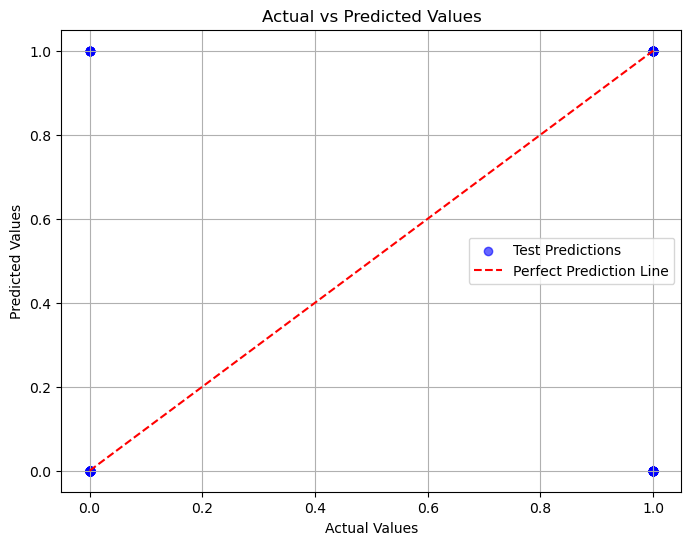

In [21]:
training_data_accuracy=accuracy_score(X_train_prediction,Y_train)
print('Accuracy score of the training data:',training_data_accuracy)

X_test_prediction=classifier.predict(X_test)
test_data_accuracy=accuracy_score(X_test_prediction,Y_test)
print('Accuracy score of the test data:',test_data_accuracy)

# Confusion Matrix
conf_matrix = confusion_matrix(Y_train, X_train_prediction)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
class_report = classification_report(Y_train, X_train_prediction)
print("Classification Report:")
print(class_report)

plt.figure(figsize=(8,6))
plt.scatter(Y_test, X_test_prediction, color='blue', label='Test Predictions', alpha=0.6)
plt.plot([0, 1], [0, 1], color='red', label='Perfect Prediction Line', linestyle='--')
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()